# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean()) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [13]:
# Revisión de valores unicos en la columna del datset users
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [14]:
# Calculo de promedio de la columna duration
before = usage["duration"].mean()

# Imputación con mediana
usage["imput_dura_med"] = usage["duration"].fillna(usage["duration"].median())
after_med = usage["imput_dura_med"].mean()

# Imputación con promedio
usage["imput_dura_mean"] = usage["duration"].fillna(usage["duration"].mean())
after_mean = usage["imput_dura_mean"].mean()

print(before)
print(after_med)
print(after_mean)

5.202237223833965
4.2627725
5.202237223833964


In [15]:
# Analisis por grupo type

usage = usage.drop(["imput_dura_med", "imput_dura_mean"], axis=1)

usa_text = usage[usage["type"]=="text"]["duration"].mean()
usa_call = usage[usage["type"]=="call"]["duration"].mean()

print(usa_text)
print(usa_call)
print(usage[usage["type"]=="text"]["type"].count())
print(usage[usage["type"]=="call"]["type"].count())

print()
print()

# Imputación con mediana
usage["icall_dura_med"] = usage[usage["type"]=="call"]["duration"].fillna(usage[usage["type"]=="call"]["duration"].median())
aftercall_med = usage["icall_dura_med"].mean()

usage["itext_dura_med"] = usage[usage["type"]=="text"]["duration"].fillna(usage[usage["type"]=="text"]["duration"].median())
aftertext_med = usage["itext_dura_med"].mean()

# Imputación con promedio

usage["icall_dura_mean"] = usage[usage["type"]=="call"]["duration"].fillna(usage[usage["type"]=="call"]["duration"].mean())
aftercall_mean = usage["icall_dura_mean"].mean()

usage["itext_dura_mean"] = usage[usage["type"]=="text"]["duration"].fillna(usage[usage["type"]=="text"]["duration"].mean())
aftertext_mean = usage["itext_dura_mean"].mean()

print(aftercall_med)
print(aftertext_med)
print(aftercall_mean)
print(aftertext_mean)

usage[usage["type"]=="call"].sort_values(by="duration").head(10)

120.0
5.099670538306902
22092
17908


5.099670538306902
120.0
5.099670538306902
120.0


,id,user_id,type,date,duration,length,icall_dura_med,itext_dura_med,icall_dura_mean,itext_dura_mean
9551,9552,10872,call,2024-02-13 05:15:52.313807845,0.0,NaN,0.0,NaN,0.0,NaN
22519,22520,13443,call,2024-04-11 21:37:28.346208655,0.0,NaN,0.0,NaN,0.0,NaN
23384,23385,12475,call,2024-04-15 19:33:57.200930022,0.0,NaN,0.0,NaN,0.0,NaN
28238,28239,12793,call,2024-05-07 18:43:24.485112126,0.0,NaN,0.0,NaN,0.0,NaN
17595,17596,11120,call,2024-03-20 14:51:53.177829445,0.0,NaN,0.0,NaN,0.0,NaN
27940,27941,12152,call,2024-05-06 10:21:35.492387308,0.0,NaN,0.0,NaN,0.0,NaN
13951,13952,13786,call,2024-03-04 03:06:59.320483012,0.0,NaN,0.0,NaN,0.0,NaN
8073,8074,12153,call,2024-02-06 12:44:58.987474686,0.0,NaN,0.0,NaN,0.0,NaN
37177,37178,10447,call,2024-06-17 05:31:23.297082426,0.0,NaN,0.0,NaN,0.0,NaN
26974,26975,13006,call,2024-05-02 01:26:58.690467260,0.0,NaN,0.0,NaN,0.0,NaN


In [16]:
usage = usage.drop(["icall_dura_med", "itext_dura_med", "icall_dura_mean",	"itext_dura_mean"], axis=1)

In [17]:
# Calculo de promedio de la columna duration
before = usage["length"].mean()

# Imputación con mediana
usage["imput_len_med"] = usage["length"].fillna(usage["length"].median())
after_med = usage["imput_len_med"].mean()

# Imputación con promedio
usage["imput_len_mean"] = usage["length"].fillna(usage["length"].mean())
after_mean = usage["imput_len_mean"].mean()

print(before)
print(after_med)
print(after_mean)

52.12739775606225
51.1756
52.12739775606224


In [18]:
usage = usage.drop(["imput_len_med", "imput_len_mean"], axis=1)
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Users:**
Al revisar los valores nulos del dataset users podemos notar que solo las columnas ***_city_*** y ***_churn_date_*** poseen valores nulos en una proporción de 11.72% y 88.35% respectivamente. Por lo tanto, los valores nulos de la columna city la decisión elegida fue la de dejarlos como nulos dado que su proporción de nulos es baja (96 registros), y tambien por evitar perder esos registros que pueden contener información util para futuros analisis; y con la columna churn_date se decidio ignorarla y no tenerla en cuenta para el analisis dado que la proporción de nulos es muy alta.

**Usage:**
Las unicas columnas con valores nulos son ***date***, ***duration*** y ***lenght*** con una proporción de 0,12%, 55.19% y 44.74% respectivamente. En la columna date los datos presentan una proporción muy baja de registros nulos, por lo que se decidió dejarlos como nulos. Con los datos de la columna duration primero se realizó un analisis de como se veria afectada la media si se reemplazaran estos valores nulos con la media y mediana de todos los datos de la columna en mención lo que nos arrojo como resultado que si hay una diferencia de 0.94, por lo que se habria decidido elegir la mediana. Sin embargo, dado que la proporción de nulos es superior al 50% de todos los datos, como ya se mencionó, se procedio hacer un analisis por grupos para hacer un manejo mas responsable de los datos, por lo que se dividieron de acuerdo con la clasificación de la columna type, texto o llamada. Se evaluó como quedaría el promedio reemplazando con la mediana o promedio de cada grupo y observamos que no hay diferencia entre elegir la mediana o la moda para hacer la imputación de cada grupo, pero la diferencia de las medias y medianas entre uno y otro si era signficativa por lo que se eleigió imputar con mediana o media respectivamente; finalmente con los datos de la columna Lenght se decidió de la misma forma imputar los datos, se realizó el calculo de la media imputando con mediana y media y se observó que la diferencia entre ambas es minima, por lo que no se hizo ningun analisis adicional y se eligió la mediana para imputar los valores nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [19]:
# explorar columnas numéricas de users

users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [20]:
users.median()

user_id    11999.5
age           47.0
dtype: float64

In [21]:
users[users["age"]==-999]["age"].value_counts()

-999    55
Name: age, dtype: int64

- En la columna `user_id` no se realiza analisis ya que no aporta información relevante para el analisis.
- En la columna `age` vemos que tiene un total de 4000 registros no nulos en donde la media es de 33.73 y desviación estandar de 123.23, un valor minimo imposible, por lo que parece a simple vista un error o sentinel. Los valores de los quartiles 25, 50 y 75 no son significativamente distantes y el valor maximo es un valor que aparentemente se ve normal, pero que muy posiblemente podamos decir que para esta variable particularmente no hay outliers en el extremo deecho. La media y mediana difieren en 13.27, siendo la mediana de 47 y como el valor de la media es menor podemos afirmar que este conjunto de datos tiene un sezgo a la izquierda y los 55 sentinels estan afectando su valor.

In [22]:
# explorar columnas numéricas de usage
usage[["duration", "length"]].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


In [23]:
usage[["duration", "length"]].median()

duration     3.5
length      50.0
dtype: float64

- Las columnas `id` y `user_id`no se les realiza analisis debido a que no aportan información relevante para el analisis de los datos.
- Las columnas: En la columna **Length** se puede ver un total de 22104 registros no nulos, una media de 52.12 y mediana de 50, por lo que podriamos afirmar que existe la posibilidad de que los datos tienen un comportamiento normal, almenos un gran porcentaje de estos, los valores extremos estan entre 0 y 1490, sin embargo el 75% de los datos tiene valores inferiores a 64, por lo que se podriamos decir que esta distribución de datos tiene un comportamiento relativamente normal con sezgo a la derecha, el rango intercuartilico es de 27, lo que nos permite tambien decir, y se puede observar con el valor de la desviación estandar de 56.61, que no hay mucha variabilidad en este conjunto de datos, sin embargo hay que analizar a profundidad los valores extremos de la derecha. Y en la columna **duration** vemos que tiene un total de 17924 datos no nulos, una media de 5.2 y mediana de 3.5, por lo que se afirma que es probable que haya datos atipicos, la desviación estandar es de 6.84, el valor minimo es de cero y el maximo de 120, el rango intercuartilico es de 5.56, por lo que vemos que unos datos muy superiores al 75% de los datos y es por ellos que confirmamos la existencia de un sezgo a la derecha.
  

In [24]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print(users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


In [25]:
users["city"].value_counts(normalize=True)

Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

In [26]:
users["plan"].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` podemos verificar que hay 3531 valores no nulos, 7 valores unicos, la ciudad con mayor frecuencia(el top) es bogotá y su valor de frecuencia es de 808 y asi mismo 96 sentinels que representan el 2.71% del total de los datos.
- La columna `plan` tiene un total de 4000 datos no nulos, 2 valores unicos, el registro mas frecuente de top es basico con un valor de 2595 y no posee sentinels ni errores aleatorios. 

In [27]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [28]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene un total de 40000 datos no nulos, 2 valores unicos, su registro mas frecuente de top es text con un valor de 22092, no posee sentinels o errores aleatorios.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  
    Del dataset users se encontraron sentinels en las columnas age y city. Asi mismo, en la columna type de usage no se encontraron errores o valores atipicos.
- ¿Qué acción tomarías?
  
  En la columna age lo que se debe hacer es eliminar los 55 sentinels ya que tienen un valor imposible que esta afectando las medidas estadisticas, y en la columna city lo que haria con esos datos seria eliminarlos tambien dado que esos 96 registros representan solo el 2.71% del total de los datos y, ademas, no podria predecir solo con la información aportada si pertenecen a una ciudad especifica por lo que tambien se descarta la posibilidad de capar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [29]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [30]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [31]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, podemos apreciar que desde el año 2022 hasta el año 2024 ha habiado un aumento de usuarios. Sin embargo, no hay datos del año 2025 y hay 40 del año 2026 lo que podriamos considerar como datos imposibles, y mas teniendo en cuenta la tendencia desde el año 2022 hasta el año 2024.

In [32]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, ... todos los registros no nulos son del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- **¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**
  En el dataset de users encontramos 40 registros del año 2026, los cuales se consideran imposibles, sin embargo, en el dataset de users hay algunos años viejos como 2022 y 2023 y no hay registros del año 2025. Y en el dataset de Usage los datos son todos del año 2024, por lo que el analisis no seria tan actualizado, debido a que ha transcurrido ya mas de un año tomando de referencia la fecha actual de de hoy.
- **¿Qué harías con ellas?**
  Del dataset de users, que es el mas completo, no eliminaria los datos del 2022 y 2023, pero tampoco los usaria para realizar ningun analisis ya que son muy antiguos, al igual que los datos del año 2026, tocaria mantenerlas como nulas para no eliminar por completo los registros que podrian contener información util para otros analisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [33]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users["age"] != -999]["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [34]:
# Reemplazar ? por NA en city

users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios

users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [35]:
# Marcar fechas futuras como NA para reg_date

users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [36]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_text = usage[usage["type"]=="text"]["duration"].isna().mean()
nulos_call =  usage[usage["type"]=="call"]["duration"].isna().mean()

print(nulos_text)
print(nulos_call)
usage["duration"].isna().mean()

0.9992757559297484
0.0


0.5519

In [37]:
# Verificación MAR en usage (Missing At Random) para length

nulos_text1 = usage[usage["type"]=="text"]["length"].isna().mean()
nulos_call1 = usage[usage["type"]=="call"]["length"].isna().mean()

print(nulos_text1)
print(nulos_call1)
usage["length"].isna().mean()

0.0
0.9993299084208175


0.4474

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Al revisar los resultados podemos concluir que los  registros nulos de las columnas **duration** y **length** no son MAR(Missing At Random) sino MNAR(Missing Not At Random), es decir su valor depende del valor de la columna type. Y esto es muy logico debido a que los planes de telefonía miden las llamadas solo en duración y no en longitud de caracteres y de igual forma los mensajes de texto se miden en numero de caracteres y no en duración, por lo tanto su valor para cada columna(duration y length), dependiendo del valor de type, sera un valor nulo o no nulo. En los resultados esto se evidencia donde al evaluar type == "text" para duración el porcentaje de nulos es 99.92% e igual la proporción de nulos para type == "call" en la columna length es de 99.93%.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [38]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:
# Renombrar columnas
usage_agg = usage_agg.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()\
    .rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=["user_id"], how="left")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [41]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               3999 non-null   int64         
 1   cant_mensajes         3999 non-null   int64         
 2   cant_llamadas         3999 non-null   int64         
 3   cant_minutos_llamada  3999 non-null   float64       
 4   first_name            3999 non-null   object        
 5   last_name             3999 non-null   object        
 6   age                   3999 non-null   float64       
 7   city                  3434 non-null   object        
 8   reg_date              3959 non-null   datetime64[ns]
 9   plan                  3999 non-null   object        
 10  churn_date            466 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 374.9+ KB


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas

user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada", "age"]].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.138285
std,2.358416,2.144238,18.168095,17.691541
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,48.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [43]:
user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada", "age"]].median()

cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.78
age                     48.00
dtype: float64

In [44]:
# Distribución porcentual del tipo de plan

user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`
  
Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

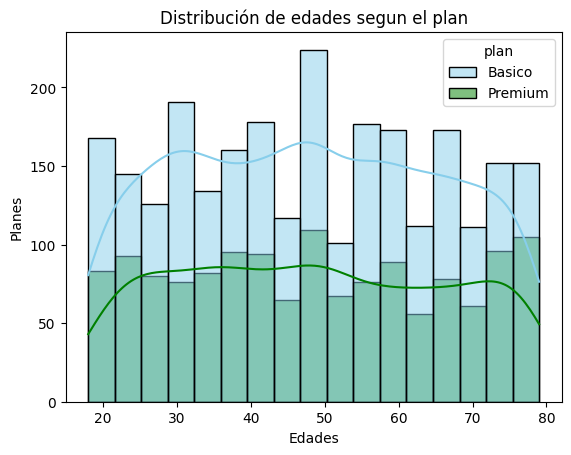

In [45]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Edades')
plt.ylabel('Planes')
plt.title('Distribución de edades segun el plan')
plt.show()

💡Insights: 
- En el frafico podemos ver que el plan básico concentra un volumen de usuarios ligeramente mayor en rangos de edad de 30, 50 y 56-67 años, mientras que el plan premium mantiene una proporción de usuarios bastante uniforme a lo largo de todas las edades (entre 20 y 80 años), sobresaliendo aquellos que estan entre los 47-50 y 75-79 años. No existe un patrón o preferencia de edad marcado para la elección de un plan específico. El tipo de distribución observada es de tipo Simétrica, ya que la mayoria de los datos se distribuye de manera uniforme entre los 20 y 80 años sin una cola que marque preferencia hacia los extremos.

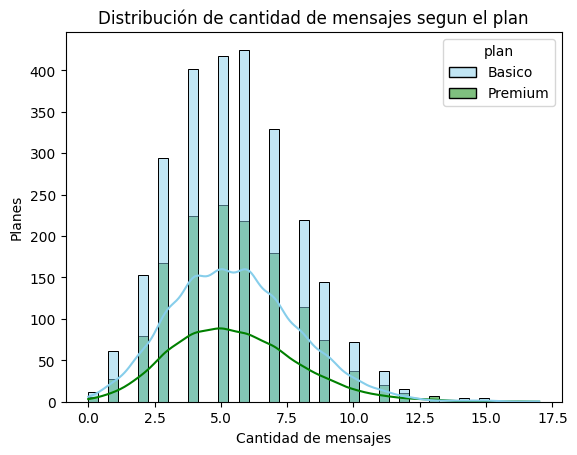

In [46]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Planes')
plt.title('Distribución de cantidad de mensajes segun el plan')
plt.show()

💡Insights: 
- En esta distribución tanto los usuarios de plan básico como los de plan premium tienden a enviar entre 4 y 7 mensajes (con su punto máximo entre 5 y 6 mensajes). Los usuarios del plan básico registran mayor volumen, pero ambos planes muestran el mismo comportamiento de consumo. Ademas, esta distribucón tiene un sesgo a la derecha (sesgo positivo), y aunque la mayoría de los datos se agrupan en valores bajos/medios (3 a 8 mensajes), la cola se extiende hacia valores altos a la derecha hasta 17 mensajes aproximadamente.

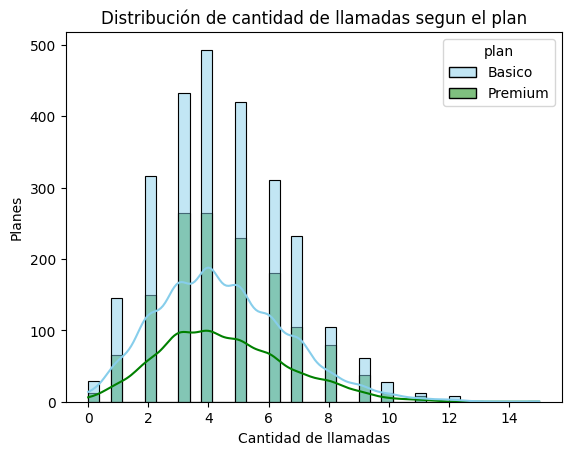

In [47]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Planes')
plt.title('Distribución de cantidad de llamadas segun el plan')
plt.show()

💡Insights: 
- Los mayoria de los usuarios de ambos planes tienden a realizar entre 3 y 5 llamadas (con el pico concentrado en 4 llamadas). A partir de las 6 llamadas, el uso disminuye significativamente para ambos tipos de planes. En esta distribución la mayor concentración esta entre 2 y 6 llamadas, y ademas tiene un sesgo a la derecha (sesgo positivo) debido a que la cola decrece y se alarga hacia la derecha (alcanzando valores de hasta 14 llamadas).

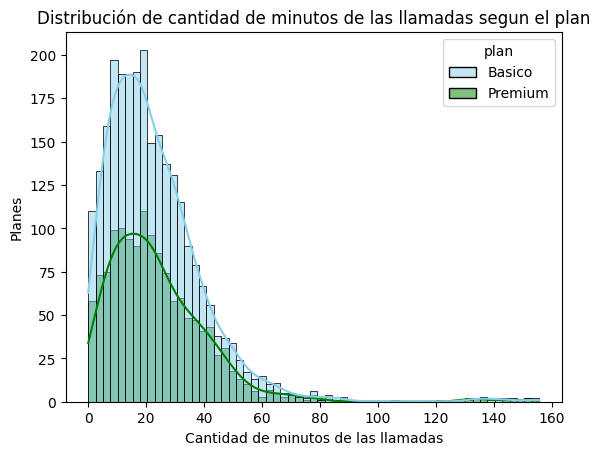

In [48]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de minutos de las llamadas')
plt.ylabel('Planes')
plt.title('Distribución de cantidad de minutos de las llamadas segun el plan')
plt.show()

💡Insights: 
- Los usuarios de ambos planes tienden a consumir principalment entre 10 y 25 minutos de llamadas aproximadamente. Aunque el plan Básico registra un volumen total de minutos mucho mayor que el Premium, ambos grupos muestran un patrón de uso muy similar en cuanto a la duración típica de sus llamadas. En esta distribución la gran mayoría de la frecuencia de los datos se concentra en valores medios (entre 0 y 40 minutos), y ademas tiene un sesgo la derecha (sesgo positivo), ya que la cola se alarga hacia la derecha alcanzando algunos valores atípicos pasados los 60 e incluso más de 140 y casi 160 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

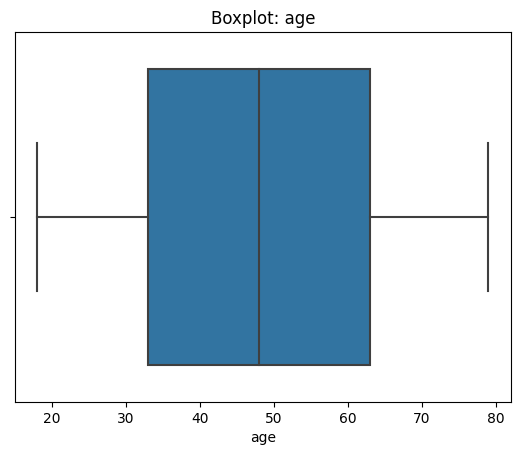

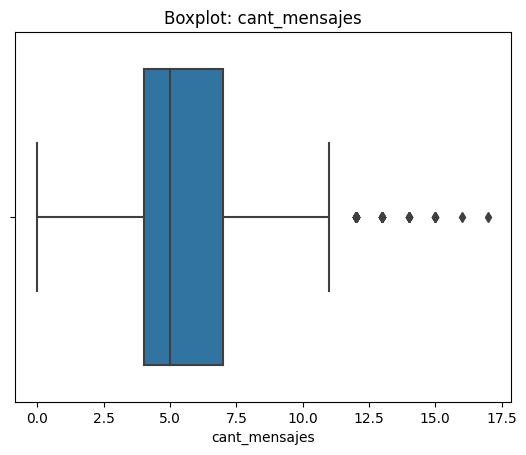

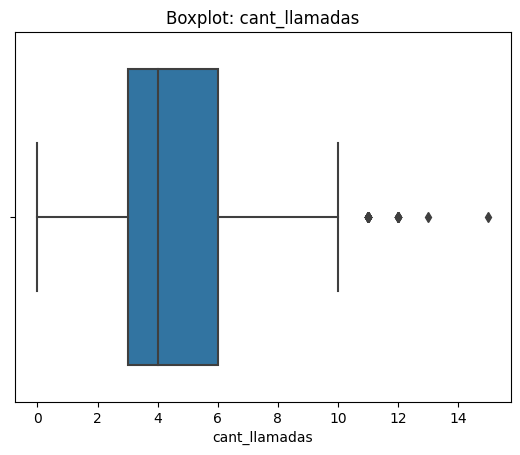

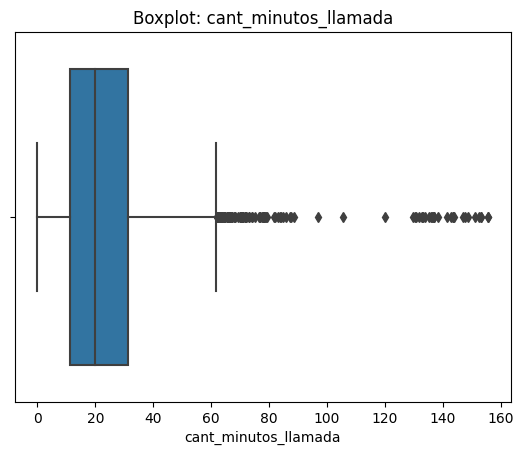

In [49]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [50]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    
    print("Calculo valor extremo de", col)
    
    #calcular Q1
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)

    #calcular Q3
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)

    #calcular IQR
    IQR = Q3 - Q1
    print('IQR: ', IQR)

    #Calculo de extremo superior
    upper = Q3 + 1.5 * IQR
    print("El valor extremos superior es:", upper)
    print()

Calculo valor extremo de cant_mensajes
Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
El valor extremos superior es: 11.5

Calculo valor extremo de cant_llamadas
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
El valor extremos superior es: 10.5

Calculo valor extremo de cant_minutos_llamada
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
El valor extremos superior es: 61.8575



In [51]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes: mantener o no outliers, porqué?**
  En cant_mensajes vemos que el valor maximo es 17 y el valor extremo superior es 11.5, la decisión que se toma es que si se mantienen los outliers debido a que es muy probable que exista algun usuario que por algun motivo (personal, laboral, negocio) pueda estar enviando esa cantidad de mensajes.
- **cant_llamadas: mantener o no outliers, porqué?**
  En cant_llamadas observamos que el valor maximo es 15 y el valor extremo superior es de 10.5, al igual que con cant_mensajes se decide mantener los outliers debido a que es un valor posible por las mismas razones expuestas y, ademas, el valor maximo no esta extremadamente distante del valor superior.
- **cant_minutos_llamada: mantener o no outliers, porqué?**
  En cant_minutos_llamada el valor superior es de 61.85 y el valor maximo es de 155.69, a pesar de que el valor maximo supera en mas del doble al valor extremo superior se decide mantener los outliers debido a que no son pocos los que estan muy por encima del valor maximo, lo que nos da a entender que hay un muy selecto grupo de usuarios que realmente consumen una gran cantidad de minutos por llamada y que se les debe dar un analisis independiente de almenos el otro 75% - 85% de los usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [52]:
# Crear columna grupo_uso

def classify_user(row):
    msm = row["cant_mensajes"]
    call = row["cant_llamadas"]

    if call < 5 and msm < 5:
        return "Bajo uso"
    else:
        if call < 10 and msm < 10:
            return 'Uso medio'
        else:
            return 'Alto uso'

user_profile["grupo_uso"] = user_profile.apply(classify_user, axis=1) 

In [53]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [54]:
# Crear columna grupo_edad

def classify_edad(row):
    age1 = row["age"]

    if age1 < 30:
        return "Joven"
    else:
        if age1 < 60:
            return "Adulto"
        else:
            return 'Adulto Mayor'

user_profile["grupo_edad"] = user_profile.apply(classify_edad, axis=1)

In [55]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

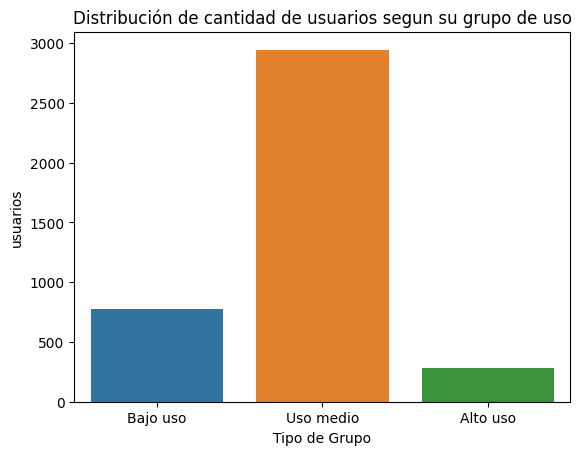

In [56]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", order=["Bajo uso", "Uso medio", "Alto uso"])
plt.xlabel('Tipo de Grupo')
plt.ylabel('usuarios')
plt.title('Distribución de cantidad de usuarios segun su grupo de uso')
plt.show()

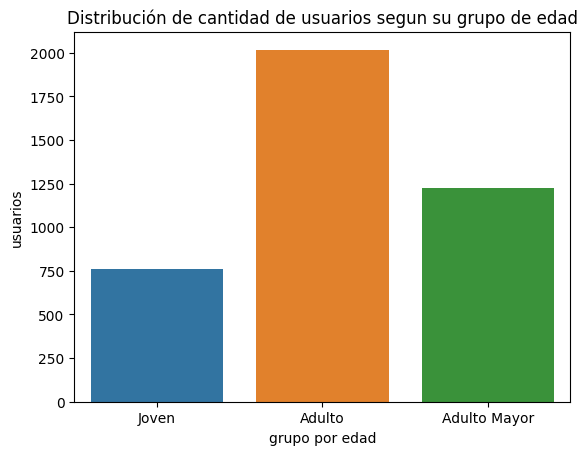

In [57]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x="grupo_edad", order=["Joven","Adulto", "Adulto Mayor"])
plt.xlabel('grupo por edad')
plt.ylabel('usuarios')
plt.title('Distribución de cantidad de usuarios segun su grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Al principio los datasets que poseian problemas eran el dataset de **users** con las columnas city y churn_date con valores nulos en una proporción de 11.72% y 88.35% respectivamente; y el dataset de **usage** en las columnas date, duration y lenght con una proporción de 0,12%, 55.19% y 44.74% respectivamente.
  
Se identificaron 2 grupos de segmentos de cliente: Por edad y por uso.

🔍 **Segmentos por Edad**
- Por edad identificamos 3 grupos: Jovenes los cuales tienen menos de 30 años, adultos los cuales estan entre los 30 y 60 años, y adulto mayor para personas mayores de 60. De los 3 el segmento que mas usuarios tiene es el de los adultos con un valor de usuarios aproximado de 2000 usuarios, luego le sigue el segmento de adultos mayores con 1250 usuarios aprox. y finalmente esta el grupo de jovenes con 750 usuarios aproximadamente.


📊 **Segmentos por Nivel de Uso**
- En el segmento por nivel de uso identificamos 3 grupos: Usuarios de bajo uso los cuales realizan menos de 5 llamadas y menos de 5 mensajes, los de uso medio que realizan mas de 5 llamadas y 5 mensajes pero al mismo tiempo menos de 10 llamadas y 10 mensajes, y por ultimo, los de alto uso que realizan mas de 10 llamadas y/0 mas de 10 mensajes. El segmento de uso medio es el de mayor cantidad de usuarios con un valor aproximado de casi 3000 usuarios, luego le sigue el segmento de bajo uso con un valor aproximado de 700 usuarios y finalmente esta el segmento de alto uso con alrededor de 300 usuarios.


Para connectaTel los segmentos mas valiosos parecen ser el de los adultos y el de uso medio debido a que la diferencia de usuarios en cada grupo es significativamente mayor a la de los otros grupos mencionados.
El patron de outliers encontrado es el de patrones con sezgo a la derecha, sezgo positivo, esto sugiere que hay un grupo de usuarios que realizan mas llamadas, mas mensajes y tambien consumen mas minutos que el resto, es decir, son un grupo exclusivo con un comportamiento diferente al de la gran mayoria de los usuarios que le estan generando muy buenas utilidades a la empresa ConnectaTel.



💡 **Recomendaciones**
- De acuerdo al patron de segmento de clientes identificados se recomendaria incluir un plan que oferte una gran cantidad de GB y minutos a un precio competitivo y no muy alto con el fin de incentivar mas el segmento de alto uso que es el que menor usuarios tiene, del mismo modo para incentivar mas el numero de usuarios jovenes, que son los que normalmente usan mas este tipo de planes ya sea por motivos personales, laboral o educativos, incluir algun otro servicio como algun tipo de drive, plataforma de musica o steaming de videos o pelicula, esto sin duda atraeria mas el mercado joven que es el menos numeroso en cantidad de usuarios. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`